# Estimating Indirect Nutrient Load from PT to Specific sites Lake Huron



In [1]:
# Standard libraries
import os
import glob
import warnings
import gc

# Data manipulation and analysis libraries
import numpy as np
import pandas as pd
import dask.dataframe as dd
import dask.array as da
import xarray as xr
import geopandas as gpd
from shapely.geometry import Point
from netCDF4 import Dataset
# geopandas 
from shapely.geometry import Point
import geopandas as gpd

# Dask diagnostics and progress bar
from dask.diagnostics import ProgressBar

# Plotting libraries
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import LinearSegmentedColormap, LogNorm
import cartopy.crs as ccrs
from pylag.processing.plot import FVCOMPlotter, create_figure, colourmap

In [3]:
# Helper functions
# Define the function to sort the files based on the time
def sort_key(file):
    filename = os.path.basename(file)
    try:
        # Extract the number after the double underscores and before the `.nc` extension
        number = int(filename.split('_')[-1].split('.')[0])
        return number
    except (IndexError, ValueError):
        # Handle filenames that do not match the pattern by returning a high number to place them last
        return float('inf')

In [6]:
##########Input Data Files and Directories##########
# -----------------------------

CW_path = "/mnt/d/Users/abolmaal/Arcgis/NASAOceanProject/GIS_layer/chosensites/test_sites"
InCoastalwetland = os.path.join(CW_path, "test_coastalwetlands_with_cxy.shp")
Coastalwetland = gpd.read_file(InCoastalwetland)

# -----------------------------
# FVCOM Particle Tracking Output Files
# -----------------------------
data_dir = '/home/abolmaal/modelling/FVCOM/Huron/output/2023'
files = glob.glob(os.path.join(data_dir, "particleload_updated_FVCOM_Huron_2323_*.nc"))
files.sort(key=sort_key)

# FVCOM grid metrics file
grid_metrics_file_name = '/home/abolmaal/modelling/FVCOM/Huron/input/gridfile/grid_metrics_huron_senseflux_Seasonal.nc'

# -----------------------------
# Direct Nutrient Load (Stream Watersheds)
# -----------------------------
Direct_Nutrient_load = '/mnt/d/Users/abolmaal/Arcgis/NASAOceanProject/GIS_layer/chosensites/test_sites/DirectTNTP_CoastalWatershed.csv'
DirectStreamWatershed_NutrientLoad = pd.read_csv(Direct_Nutrient_load)
updated_files = glob.glob(os.path.join(data_dir, "particleload_updated_FVCOM_Huron_2323_*.nc"))
updated_files.sort(key=sort_key)
# Alias for clarity
nc_files = updated_files
print(nc_files)


#set the crs of cw_avg to 3174
Coastalwetland.crs = 'EPSG:3174'


# Output directory
output_path = CW_path
out_dir = os.path.join(output_path, "TotalNP", "2023", "new")
os.makedirs(out_dir, exist_ok=True)

release_times = ["2301", "2302", "2303", "2304", "2305", "2306", "2307", "2308", "2309", "2310", "2311"]



['/home/abolmaal/modelling/FVCOM/Huron/output/2023/particleload_updated_FVCOM_Huron_2323_JanFeb_1.nc', '/home/abolmaal/modelling/FVCOM/Huron/output/2023/particleload_updated_FVCOM_Huron_2323_FebMar_2.nc', '/home/abolmaal/modelling/FVCOM/Huron/output/2023/particleload_updated_FVCOM_Huron_2323_MarApr_3.nc', '/home/abolmaal/modelling/FVCOM/Huron/output/2023/particleload_updated_FVCOM_Huron_2323_AprMay_4.nc', '/home/abolmaal/modelling/FVCOM/Huron/output/2023/particleload_updated_FVCOM_Huron_2323_MayJun_5.nc', '/home/abolmaal/modelling/FVCOM/Huron/output/2023/particleload_updated_FVCOM_Huron_2323_JunJul_6.nc', '/home/abolmaal/modelling/FVCOM/Huron/output/2023/particleload_updated_FVCOM_Huron_2323_JulAug_7.nc', '/home/abolmaal/modelling/FVCOM/Huron/output/2023/particleload_updated_FVCOM_Huron_2323_AugSep_8.nc', '/home/abolmaal/modelling/FVCOM/Huron/output/2023/particleload_updated_FVCOM_Huron_2323_SepOct_9.nc', '/home/abolmaal/modelling/FVCOM/Huron/output/2023/particleload_updated_FVCOM_Huro

# Find the first Intersection PT with Cosatal wetlands

In [7]:
def save_first_intersection_per_file_with_stats(nc_file, CW, output_dir, release_time_str, cw_level):
    import os, gc
    import numpy as np
    import xarray as xr
    import geopandas as gpd

    print(f"🔍 Processing {os.path.basename(nc_file)} with release time {release_time_str} for {cw_level}...")

    # --- Ensure CW is in 3174 (same as particle points) ---
    if CW.crs is None:
        raise ValueError("CW GeoDataFrame has no CRS set.")
    if CW.crs.to_epsg() != 3174:
        CW_3174 = CW.to_crs("EPSG:3174")
    else:
        CW_3174 = CW

    keep_cols = ['geometry', 'CW_Aream2', 'CW_Id', 'Coastal_Id','fid_1','CW_cx','CW_cy','Site','MGRS_Tile']
    keep_cols = [c for c in keep_cols if c in CW_3174.columns]  # avoid KeyError if some missing
    CW_3174 = CW_3174[keep_cols]

    with xr.open_dataset(nc_file) as ds:
        selected = ds[['time', 'group_id', 'particle_id', 'longitude', 'latitude',
                       'StreamTN_gramdayparticle', 'StreamTP_gramdayparticle']].copy()

        # Fix longitudes > 180° (safe assignment)
        lon = selected['longitude'].values
        selected['longitude'].values = np.where(lon > 180, lon - 360, lon)

        df = selected.to_dataframe().reset_index()

    # GeoDataFrame in WGS84 then project to 3174
    gdf = gpd.GeoDataFrame(
        df,
        geometry=gpd.points_from_xy(df['longitude'], df['latitude']),
        crs="EPSG:4326"
    ).to_crs("EPSG:3174")

    total_particles = int(gdf['particle_id'].nunique())

    # --- Do spatial join once (fast + correct) ---
    joined_all = gpd.sjoin(
        gdf,
        CW_3174,
        how="inner",
        predicate="intersects"
    )

    if joined_all.empty:
        print(f"⚠️ No intersections found for {release_time_str} with {cw_level}.")
        gc.collect()
        return 0.0, total_particles, 0

    # First intersection per particle (after join)
    joined_all = joined_all.sort_values(by=['particle_id', 'time'])
    first = joined_all.drop_duplicates(subset='particle_id', keep='first')

    output_csv = os.path.join(output_dir, f"intersection_{release_time_str}_{cw_level}.csv")
    first.to_csv(output_csv, index=False)

    intersected_particles = int(first['particle_id'].nunique())
    percentage = (intersected_particles / total_particles) * 100 if total_particles else 0.0

    print(f"✅ {intersected_particles}/{total_particles} particles intersected ({percentage:.2f}%) — saved to {output_csv}")

    gc.collect()
    return float(percentage), total_particles, intersected_particles


In [8]:
# run the finction 
import os
from pathlib import Path
import pandas as pd
import traceback

Path(output_path).mkdir(parents=True, exist_ok=True)

# Ensure these match
assert len(updated_files) == len(release_times), (
    f"updated_files ({len(updated_files)}) and release_times ({len(release_times)}) must match"
)

Inundation = [Coastalwetland]
cw_levels  = ["Coastalwetland"]

# Simple, consistent naming
summary_name_map = {lvl: f"Intersection_summary.csv" for lvl in cw_levels}

for CW, cw_level in zip(Inundation, cw_levels):
    print(f"\n⏳ Running intersections for cw_level = {cw_level}")

    summary_data = []

    for nc_file, rtime in zip(updated_files, release_times):
        try:
            pct, total, intersected = save_first_intersection_per_file_with_stats(
                nc_file, CW, output_path, rtime, cw_level=cw_level
            )
        except Exception as e:
            print(f"❌ Error for cw_level={cw_level}, rtime={rtime}: {e}")
            traceback.print_exc()
            pct, total, intersected = 0.0, 0, 0

        summary_data.append({
            "release_time": rtime,
            "total_particles": total,
            "intersected_particles": intersected,
            "percentage": round(float(pct), 2),
            "cw_level": cw_level,
            "nc_file": os.path.basename(nc_file),
        })

    summary_df = pd.DataFrame(summary_data)

    summary_csv = os.path.join(output_path, summary_name_map[cw_level])
    summary_df.to_csv(summary_csv, index=False)

    print(f"📄 Saved summary to {summary_csv}")
    print(f"✅ Exists after save? {Path(summary_csv).exists()}")



⏳ Running intersections for cw_level = Coastalwetland
🔍 Processing particleload_updated_FVCOM_Huron_2323_JanFeb_1.nc with release time 2301 for Coastalwetland...
✅ 97/8550 particles intersected (1.13%) — saved to /mnt/d/Users/abolmaal/Arcgis/NASAOceanProject/GIS_layer/chosensites/test_sites/intersection_2301_Coastalwetland.csv
🔍 Processing particleload_updated_FVCOM_Huron_2323_FebMar_2.nc with release time 2302 for Coastalwetland...
✅ 37/8550 particles intersected (0.43%) — saved to /mnt/d/Users/abolmaal/Arcgis/NASAOceanProject/GIS_layer/chosensites/test_sites/intersection_2302_Coastalwetland.csv
🔍 Processing particleload_updated_FVCOM_Huron_2323_MarApr_3.nc with release time 2303 for Coastalwetland...
✅ 252/8550 particles intersected (2.95%) — saved to /mnt/d/Users/abolmaal/Arcgis/NASAOceanProject/GIS_layer/chosensites/test_sites/intersection_2303_Coastalwetland.csv
🔍 Processing particleload_updated_FVCOM_Huron_2323_AprMay_4.nc with release time 2304 for Coastalwetland...
✅ 107/8550 

In [11]:
# Estimate Indirect N and P loads for each CW site

import os
import glob
import pandas as pd

year = 23

def calculate_indirect_cw_flux(intersection_df):
    intersection_df['time'] = pd.to_datetime(intersection_df['time'])

    grouped = intersection_df.groupby('CW_Id', as_index=False).agg(
        totalTN_per_CW_Id=('StreamTN_gramdayparticle', 'sum'),
        totalTP_per_CW_Id=('StreamTP_gramdayparticle', 'sum'),
        CW_Aream2=('CW_Aream2', 'first'),
        CW_cx=('CW_cx', 'first'),
        CW_cy=('CW_cy', 'first'),
        group_ids=('group_id', lambda x: list(set(x))),
        particle_ids=('particle_id', lambda x: list(set(x))),
        count_group_id=('group_id', pd.Series.nunique),
        count_cw_id=('group_id', 'count'),
    )

    # Calculate total loads in g/m²/yr
    grouped['TotalIndirectCW_TN_grm2yr'] = (grouped['totalTN_per_CW_Id'] * 365) / grouped['CW_Aream2']
    grouped['TotalIndirectCW_TP_grm2yr'] = (grouped['totalTP_per_CW_Id'] * 365) / grouped['CW_Aream2']

    # 🔴 Remove extreme TN values > 10000 g/m²/yr
    #grouped = grouped[grouped['TotalIndirectCW_TN_grm2yr'] <= 10000]

    return grouped

def process_intersection_category(output_path, category):
    pattern = os.path.join(output_path, f"intersection_{year}??_{category}.csv")
    intersection_files = glob.glob(pattern)

    if not intersection_files:
        print(f"⚠️ No files found for category: {category}")
        return None

    # Read and tag each file with release_time
    intersection_dfs = []
    for file in intersection_files:
        df = pd.read_csv(file)
        df['release_time'] = os.path.basename(file).split('_')[1]
        intersection_dfs.append(df)

    intersection_df = pd.concat(intersection_dfs, ignore_index=True)
    
    # Save combined CSV
    combined_csv = os.path.join(output_path, f"intersection_all_{year}_{category}.csv")
    intersection_df.to_csv(combined_csv, index=False)

    # Calculate and return indirect CW flux
    flux_df = calculate_indirect_cw_flux(intersection_df)

    # Optionally save the output
    flux_csv = os.path.join(output_path, f"Indirect_CW_{category}_{year}.csv")
    flux_df.to_csv(flux_csv, index=False)
    
    print(f"✅ Processed category '{category}' → {len(flux_df)} CWs saved to {flux_csv}")
    return flux_df


In [12]:
year_suffix = 23
print(f"Processing indirect nutrient loads for year suffix: {year_suffix}")

# Example usage for multiple categories
categories = ["Coastalwetland"]


results = {}
for cat in categories:
    results[cat] = process_intersection_category(output_path, cat)

Processing indirect nutrient loads for year suffix: 23
✅ Processed category 'Coastalwetland' → 4 CWs saved to /mnt/d/Users/abolmaal/Arcgis/NASAOceanProject/GIS_layer/chosensites/test_sites/Indirect_CW_Coastalwetland_23.csv


# Plot 

In [ ]:
import seaborn as sns
plt.savefig(os.path.join(output_path, f"Direct_vs_Indirect_loads_by_site_symlog_{year_suffix}.png"), dpi=150)


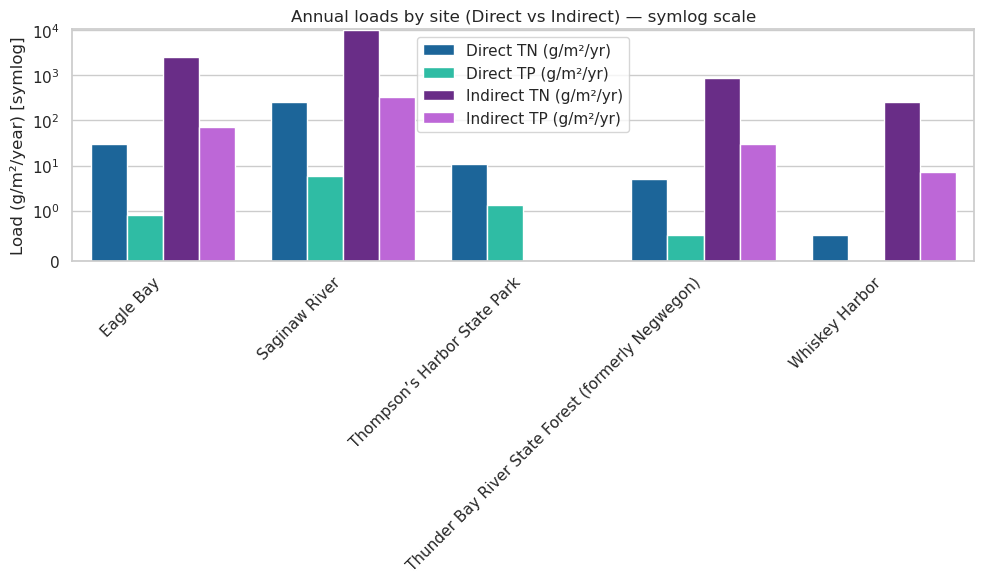

In [28]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

csv_path = "/mnt/d/Users/abolmaal/Arcgis/NASAOceanProject/GIS_layer/chosensites/ChosenSitesalongLakeHuron_NPLoad.csv"

# --- robust read (comma/tab safe) ---
df = pd.read_csv(csv_path, sep=None, engine="python", encoding="utf-8-sig")
df.columns = df.columns.str.strip()

# find label column robustly
label_col = next((c for c in df.columns if c.strip().lower() == "label"), None)
if label_col is None:
    raise ValueError(f"Couldn't find 'Label'. Columns: {df.columns.tolist()}")

# aggregate if duplicate labels exist (mean); if unique it won't change
dfg = df.groupby(label_col, as_index=False).mean(numeric_only=True)

cols_yr = [
    "CoastalWatershedDirectTN_grm2yr",
    "CoastalWatershedDirectTP_grm2yr",
    "TotalIndirectCW_TN_grm2yr",
    "TotalIndirectCW_TP_grm2yr",
]

missing = [c for c in cols_yr if c not in dfg.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}\nAvailable: {dfg.columns.tolist()}")

# Pretty names (used in legend)
pretty = {
    "CoastalWatershedDirectTN_grm2yr": "Direct TN (g/m²/yr)",
    "CoastalWatershedDirectTP_grm2yr": "Direct TP (g/m²/yr)",
    "TotalIndirectCW_TN_grm2yr": "Indirect TN (g/m²/yr)",
    "TotalIndirectCW_TP_grm2yr": "Indirect TP (g/m²/yr)",
}

# Long format for seaborn
plot_df = dfg.melt(
    id_vars=[label_col],
    value_vars=cols_yr,
    var_name="Metric",
    value_name="Load"
)
plot_df["Metric"] = plot_df["Metric"].map(pretty)

# --- choose YOUR colors here ---
palette = {
    "Direct TN (g/m²/yr)"  : "#0768ae",  # blue
    "Direct TP (g/m²/yr)"  : "#18d3b4",  # orange
    "Indirect TN (g/m²/yr)": "#6e1e96",  # green
    "Indirect TP (g/m²/yr)": "#c754ea",  # red
}

# Optional: order labels (example: by Indirect TN descending)
# order = (
#     dfg.sort_values("TotalIndirectCW_TN_grm2yr", ascending=False)[label_col].astype(str).tolist()
# )
order = dfg[label_col].astype(str).tolist()

sns.set_theme(style="whitegrid")
plt.figure(figsize=(max(10, 0.65 * len(order)), 6))

ax = sns.barplot(
    data=plot_df,
    x=label_col,
    y="Load",
    hue="Metric",
    order=order,
    palette=palette
)

# symlog keeps zeros safe + shows small values better
ax.set_yscale("symlog", linthresh=1)   # try linthresh=5 or 10 if you want more "linear" near 0

ax.set_xlabel("")
ax.set_ylabel("Load (g/m²/year) [symlog]")
ax.set_title("Annual loads by site (Direct vs Indirect) — symlog scale")
plt.xticks(rotation=45, ha="right")
plt.legend(title="", frameon=True)
plt.tight_layout()
plt.savefig(os.path.join(output_path, f"Direct_vs_Indirect_loads_by_site_symlog_{year_suffix}.png"), dpi=150)
plt.show()